In [54]:
import json

import gc_utils
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [60]:
sim = "m12b"
snap_min = 46
snap_max = 590

sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

main_dict = {"m12b": 39810368, "m12c": 89423951, "m12f": 53854632, "m12i": 25236877, "m12m": 79502363}

main_halo_tid = 25236877


In [61]:
sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)
main_halo = sim_codes[sim]["halo"]

In [62]:
pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]


snap_lst = pub_snaps[(snap_min <= pub_snaps["index"]) & (pub_snaps["index"] <= snap_max)]["index"].values
time_lst = pub_snaps[(snap_min <= pub_snaps["index"]) & (pub_snaps["index"] <= snap_max)]["time_Gyr"].values

In [63]:
# halt = gc_utils.get_halo_tree(sim, sim_dir)

In [65]:
# halo_idx = np.where(halt["tid"] == main_halo)[0][0]

# test = []
# for snap in snap_lst:
#     halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
#     halo_idx = np.where(halt["tid"] == halo_tid)[0][0]
#     test.append(halt["radius"][halo_idx])

# test = np.array(test)

In [66]:
m12b_arr = np.array(
    [5.5, 5.5, 0, 12.5, 1000, 18, 5.5, 18, 0, 65, 65, 100, 125, 130, 130, 40, 30, 50, 20, 1000, 280, 310]
)

m12c_arr = np.array([2, 4, 4, 3.5, 8, 3.5, 1.5, 2.5, 28, 20, 4, 75, 82, 78, 80, 70, 85, 87, 82, 82, 75, 100])

m12f_arr = np.array(
    [3.5, 3, 7, 10, 12, 12, 3, 3, 37, 37, 42, 52, 62, 100, 38, 80, 105, 130, 75, 75, 210, 250]
)

m12i_arr = np.array(
    [2, 1, 0.7, 4, 0, 0, 0, 8, 35, 10, 30, 45, 100, 112, 105, 1000, 180, 145, 145, 190, 175, 220]
)

m12m_arr = np.array([0, 15, 23, 0, 5, 80, 60, 105, 140, 160, 150, 125, 160, 115, 80, 155])

data_dict = {"m12b": m12b_arr, "m12c": m12c_arr, "m12f": m12f_arr, "m12i": m12i_arr, "m12m": m12m_arr}

Text(0, 0.5, 'Radius Below 0.05 Error')

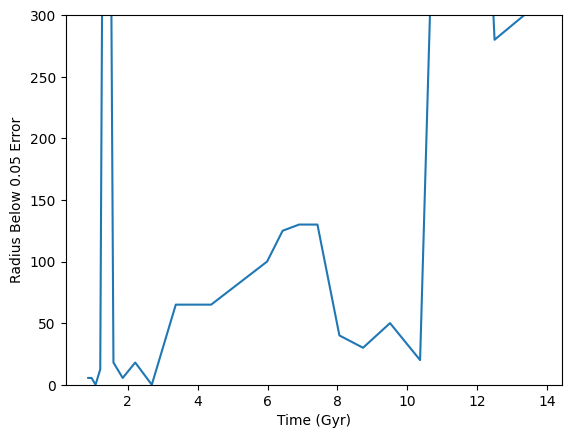

In [67]:
plt.plot(time_lst, data_dict[sim])
plt.ylim(0, 300)

plt.xlabel("Time (Gyr)")
plt.ylabel("Radius Below 0.05 Error")

In [68]:
# pro = data_dict[sim] / test

# plt.plot(time_lst, pro)
# plt.ylim(0, 1)

# plt.xlabel("Time (Gyr)")
# plt.ylabel("Fraction of Radius Below 0.05 Error")

In [ ]:
pub_snaps

,index,scale_factor,redshift,time_Gyr,lookback_time_Gyr,time_width_Myr
0,20,0.090909,10.000000,0.487865,13.310882,12.6415
1,23,0.095454,9.476195,0.524880,13.273867,12.4377
2,26,0.100000,9.000000,0.562782,13.235965,12.7314
3,29,0.104762,8.545455,0.603415,13.195332,13.6484
4,33,0.111111,8.000001,0.659029,13.139718,14.0548
5,37,0.118056,7.470585,0.721681,13.077066,15.8391
6,41,0.125000,7.000000,0.786178,13.012568,16.2941
7,46,0.133117,6.512194,0.863829,12.934918,15.7217
8,52,0.142857,6.000002,0.960115,12.838632,16.2771
9,59,0.153968,5.494843,1.073930,12.724816,16.5120


(array([3.117e+03, 5.400e+02, 1.390e+02, 4.900e+01, 1.500e+01, 7.000e+00,
        2.000e+00, 0.000e+00, 1.000e+00, 4.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
        220., 230., 240., 250.]),
 [<matplotlib.patches.Polygon at 0x309b0d670>])

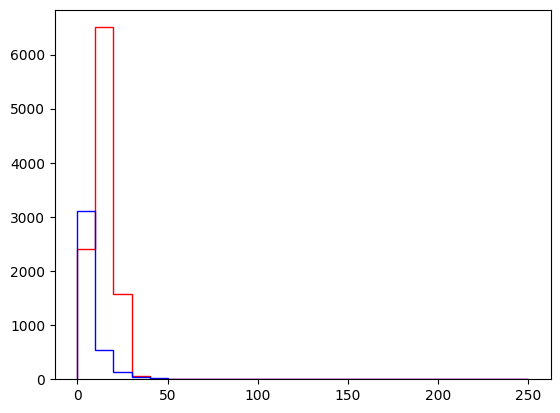

In [75]:
it = 0
snap = 214
sim = "m12m"

sim_dir = "/Users/z5114326/Documents/simulations/"
proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

it_id = gc_utils.iteration_name(it)
snap_id = gc_utils.snapshot_name(snap)

snp_dat = proc_data[it_id]["snapshots"][snap_id]
igrp_msk = snp_dat["group_id"][()] == 0
egrp_msk = snp_dat["group_id"][()] != 0
acc_msk = snp_dat["now_accreted"][()] == 1

ir = snp_dat["r"][igrp_msk & acc_msk]
er = snp_dat["r"][egrp_msk & acc_msk]

bins = np.arange(0, 260, 10)
plt.hist(ir, bins=bins, histtype="step", color="r", density=False)
plt.hist(er, bins=bins, histtype="step", color="b", density=False)

In [78]:
m12b = [0.041, 0.048, 0.078, 0.168, 0.104, 0.116]
m12c = [0.058, 0.046, 0.056, 0.076, 0.096, 0.082, 0.083, 0.039]
m12f = [0.050, 0.070, 0.083, 0.058, 0.033, 0.192, 0.041, 0.079, 0.098]
m12i = [0.061, 0.030, 0.069, 0.054, 0.045, 0.043]
m12m = [0.049, 0.078, 0.170, 0.064]

m12b_med = np.median(m12b)
m12c_med = np.median(m12c)
m12f_med = np.median(m12f)
m12i_med = np.median(m12f)
m12m_med = np.median(m12m)

np.mean([m12b_med, m12c_med, m12f_med, m12i_med, m12m_med])

0.0738